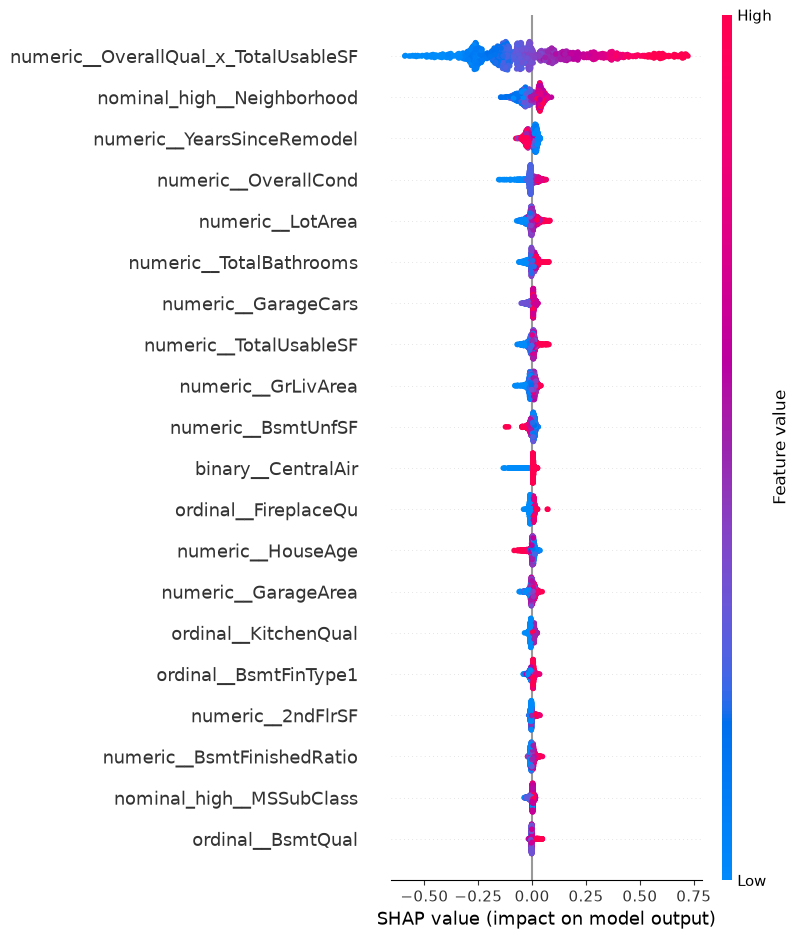

In [12]:
# Needed some help from AI here, to extract out information from scikit-learn's nested objects.
import sys
import os
import joblib
import pandas as pd
import shap

sys.path.append(os.path.abspath(os.path.join("..")))
model_path = os.path.join("../models", "xgboost_baseline_v2.joblib")
test_df_path = os.path.join("../data", "raw", "test.csv")

# Load model and data
model = joblib.load(model_path)
test_df = pd.read_csv(test_df_path)

# Isolate the Preprocessor and the XGBoost model
master_pipeline = model.regressor_
preprocessor = master_pipeline.named_steps['preprocessor']
my_model = master_pipeline.named_steps['model']

# Transform testing data
test_df_transformed = preprocessor.transform(test_df)

# Safely reattach feature names from the master preprocessor
feature_names = preprocessor.named_steps['branching'].get_feature_names_out()
test_df_transformed_df = pd.DataFrame(test_df_transformed, columns=feature_names)

# Calculate SHAP values
explainer = shap.TreeExplainer(my_model)
shap_values = explainer.shap_values(test_df_transformed_df)

# Pass both the SHAP values AND the DataFrame to get colors and names
shap.summary_plot(shap_values, test_df_transformed_df)

# Interpreting SHAP values

* The Y-Axis (Top to Bottom): Features at the very top are the most important. Features at the bottom matter the least.

* The Color: Red dots mean the feature has a High value (e.g., a massive house). Blue dots mean the feature has a Low value (e.g., a tiny house).

* The X-Axis (Left to Right): If dots are pulled to the right, it means they increased the predicted house price. If they are pulled to the left, they decreased the predicted house price.

# Observations

* The house prices is mainly determined by OverallQual_x_TotalUsableSF. At the top row, the bright red dots are stretched far to the right meaning high quality and large size drastically increase the price. The blue dots (low quality/small size) are pulled to the left, driving the price down.

* The second most important feature is Neighborhood. Due to Target Encoder, it learned that being in an expensive neighborhood (red dots) pushes the predicted price up, while being in a cheaper neighborhood (blue dots) pushes price down.


* The third most important feature is YearsSinceRemodel. Interestingly the red dots are on the left side of the center line, and the blue dots are on the right! This means if a house has a High value for years since remodel, it explicitly decreases the house's value. If it has a Low value (houses recently remodeled), it increases the value.

# SHAP vs Standard Feature Importance

* XGBoost's native feature importance (XGBoost's built-in feature_importances_ attribute) only tells how often a feature was used to split a tree, or how much it improved the loss function. It does not tell if the feature pushed the price up or down.

* **Example:** Standard feature importance only tells us that a feature like 'YearsSinceRemodel' is important, but it doesn't tell us if it pushes the price up or down. SHAP proves the model's logic, by showing that houses remodelled long time ago decrease value while houses remodelled freshly increase value of SalePrice.